In [1]:
import os

def check_matching(image_dir, label_dir):
    image_files = set([os.path.splitext(f)[0] for f in os.listdir(image_dir)])
    label_files = set([os.path.splitext(f)[0] for f in os.listdir(label_dir)])

    missing_labels = image_files - label_files
    missing_images = label_files - image_files

    print("Missing labels:", len(missing_labels))
    print("Missing images:", len(missing_images))

check_matching("Dataset_helmet_resplit/images/train",
               "Dataset_helmet_resplit/labels/train")

Missing labels: 12
Missing images: 0


In [2]:
def count_images(path):
    return len(os.listdir(path))

print("Train:", count_images("Dataset_helmet_resplit/images/train"))
print("Val:", count_images("Dataset_helmet_resplit/images/val"))
print("Test:", count_images("Dataset_helmet_resplit/images/test"))

Train: 2020
Val: 433
Test: 434


In [3]:
from collections import Counter
import os

class_names = ['Helmet', 'Motorbike', 'NoHelmet', 'PNumber']

def count_classes(label_path):
    counter = Counter()
    for file in os.listdir(label_path):
        with open(os.path.join(label_path, file), 'r') as f:
            for line in f:
                cls = int(line.split()[0])
                counter[class_names[cls]] += 1
    return counter

train_counts = count_classes("Dataset_helmet_resplit/labels/train")
print(train_counts)

Counter({'Motorbike': 3013, 'Helmet': 2306, 'NoHelmet': 2033, 'PNumber': 1480})


In [4]:
import numpy as np

def objects_per_image(label_path):
    counts = []
    for file in os.listdir(label_path):
        with open(os.path.join(label_path, file), 'r') as f:
            counts.append(len(f.readlines()))
    return np.mean(counts), np.max(counts)

mean_objs, max_objs = objects_per_image("Dataset_helmet_resplit/labels/train")
print("Average objects:", mean_objs)
print("Max objects in one image:", max_objs)

Average objects: 4.398406374501992
Max objects in one image: 21


In [5]:
import numpy as np

def bbox_stats(label_path):
    areas = []
    for file in os.listdir(label_path):
        with open(os.path.join(label_path, file), 'r') as f:
            for line in f:
                parts = line.split()
                w = float(parts[3])
                h = float(parts[4])
                areas.append(w*h)
    return np.mean(areas), np.min(areas), np.max(areas)

mean_area, min_area, max_area = bbox_stats("Dataset_helmet_resplit/labels/train")
print("Mean area:", mean_area)
print("Min area:", min_area)
print("Max area:", max_area)

Mean area: 0.077505463724551
Min area: 4.2724609374999996e-06
Max area: 0.9421875


In [6]:
import os
import numpy as np
import pandas as pd
import plotly.express as px
from collections import Counter

base_path = "Dataset_helmet_resplit/labels/train"
class_names = ['Helmet', 'Motorbike', 'NoHelmet', 'PNumber']

data = []

for file in os.listdir(base_path):
    with open(os.path.join(base_path, file), 'r') as f:
        for line in f:
            parts = line.strip().split()
            cls = int(parts[0])
            x, y, w, h = map(float, parts[1:])
            area = w * h
            aspect_ratio = w / h if h != 0 else 0

            data.append({
                "class": class_names[cls],
                "width": w,
                "height": h,
                "area": area,
                "aspect_ratio": aspect_ratio
            })

df = pd.DataFrame(data)

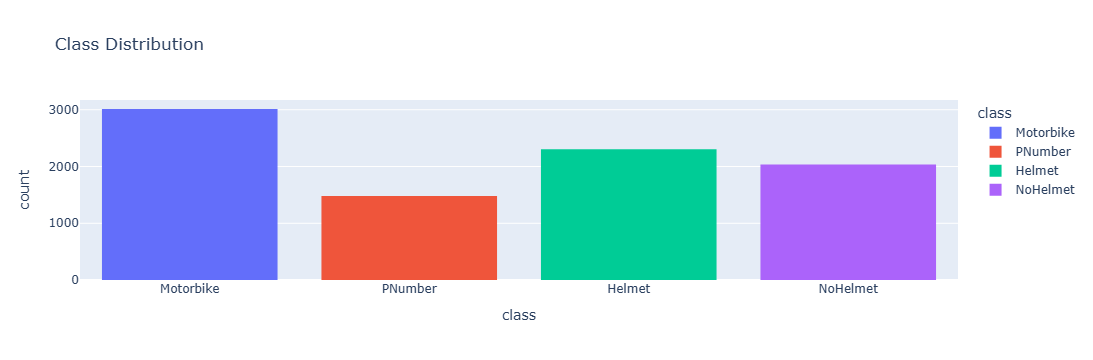

In [7]:
fig = px.histogram(df, x="class", title="Class Distribution", color="class")
fig.show()

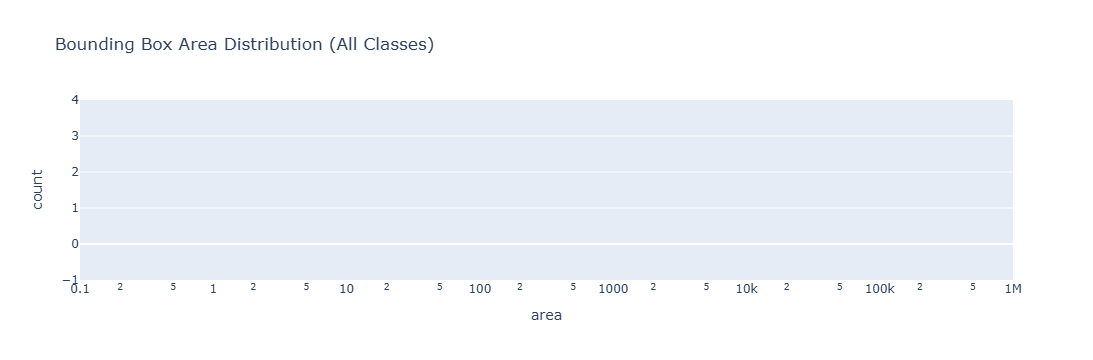

In [8]:
fig = px.histogram(df, x="area", nbins=100,
                   title="Bounding Box Area Distribution (All Classes)")
fig.update_layout(xaxis_type="log")
fig.show()

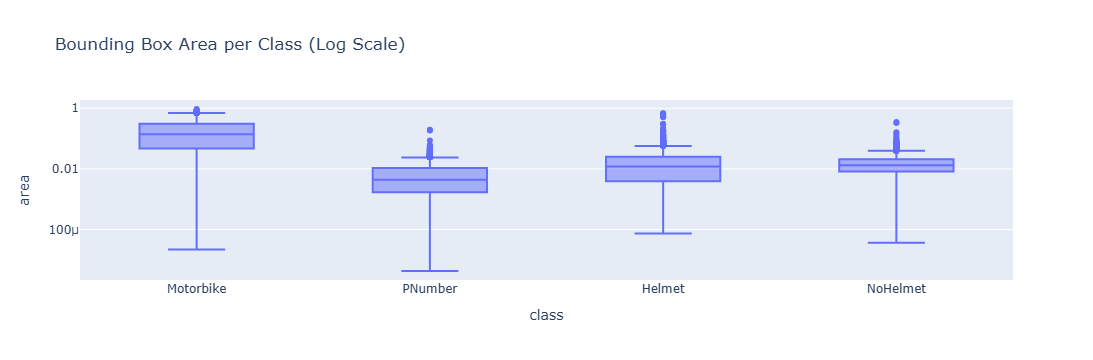

In [9]:
fig = px.box(df, x="class", y="area",
             title="Bounding Box Area per Class (Log Scale)")
fig.update_layout(yaxis_type="log")
fig.show()

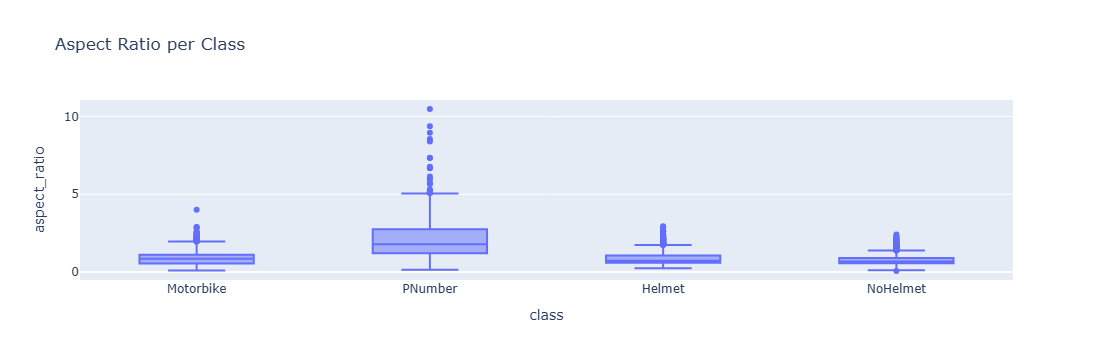

In [10]:
fig = px.box(df, x="class", y="aspect_ratio",
             title="Aspect Ratio per Class")
fig.show()

In [11]:
small_objects = df[df["area"] < 0.01]
print("Small object %:", len(small_objects) / len(df) * 100)

Small object %: 34.080615942028984


In [13]:
import os
import pandas as pd
import numpy as np

base_path = "Dataset_helmet_resplit/labels/train"
class_names = ['Helmet', 'Motorbike', 'NoHelmet', 'PNumber']

data = []

for file in os.listdir(base_path):
    with open(os.path.join(base_path, file), 'r') as f:
        for line in f:
            parts = line.strip().split()
            cls = int(parts[0])
            w, h = float(parts[3]), float(parts[4])
            area = w * h
            
            data.append({
                "class": class_names[cls],
                "area": area
            })

df = pd.DataFrame(data)

summary = df.groupby("class")["area"].describe(percentiles=[0.25, 0.5, 0.75])

five_number = summary[["min", "25%", "50%", "75%", "max"]]

print(five_number)

                min       25%       50%       75%       max
class                                                      
Helmet     0.000073  0.003898  0.011954  0.025104  0.686873
Motorbike  0.000022  0.046484  0.137500  0.305282  0.942187
NoHelmet   0.000037  0.008234  0.013063  0.020625  0.351270
PNumber    0.000004  0.001701  0.004336  0.010578  0.196501
